SpatialFusion can be used on H&E images directly without spatial transcriptomics to uncover niches. Because the pre-trained model uses both gene expression and H&E, the niches are 'molecularly-informed' even if run on H&E only. 

In this tutorial we will show how you can run the SpatialFusion pipeline on an H&E image.

## Setup

In [ ]:
# Set the GPU you want to use and confirm that CUDA is available
import os
import torch
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
torch.cuda.is_available()

True

In [6]:
# Standard library
import logging
import warnings
import pathlib as pl

# Third-party libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import shapely.wkb
import tifffile
import timm
import cv2
from PIL import Image
from tqdm.notebook import tqdm
from torchvision import transforms
from skimage.color import separate_stains, hed_from_rgb

# Warning filters
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# Step 0: Run nuclei segmentation

The minimum input to SpatialFusion is the UNI embeddings of each of the patches centered around cells, as the method is single-cell resolution. This means that to construct the UNI embeddings you need the x and y coordinates of the cell centroids. To obtain them, you can just run the nuclei segmentation method of your choice. Cellpose is an easy and good option (https://www.cellpose.org/).

Here we show an example running Cellpose on the tutorial WSI crop.

### Optional example: run Cellpose

This next cell is only an example of how to run nuclei segmentation. You will need Cellpose installed to execute it. If you want to keep going with the provided segmentation results, you can start from the following cell.

In [ ]:
from cellpose import models

use_gpu = torch.cuda.is_available()

model_nuclei = models.CellposeModel(gpu=use_gpu)
model_nuclei.pretrained_model = 'nuclei'

img_path = 'data/wsi_crop.ome.tif'

# --- Load image ---
image = tifffile.imread(img_path)

# --- Ensure RGB ---
if image.ndim == 2:
    image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
elif image.shape[-1] > 3:
    image = image[..., :3]

# Convert to float in [0,1] (IMPORTANT for skimage)
image_float = image.astype(np.float32) / 255.0

# --- H&E stain separation ---
hed = separate_stains(image_float, hed_from_rgb)

# Hematoxylin channel (nuclei)
hematoxylin = hed[..., 0]

# --- Normalize for Cellpose ---
# Invert because nuclei should be bright for Cellpose
hematoxylin = -hematoxylin

# Rescale to 0–1
hematoxylin -= hematoxylin.min()
hematoxylin /= (hematoxylin.max() + 1e-8)

# Convert to 8-bit (optional but often helpful)
hematoxylin_uint8 = (hematoxylin * 255).astype(np.uint8)

print("Running Cellpose on hematoxylin channel...")

nuclei_labels = model_nuclei.eval(
    hematoxylin_uint8,
    channels=[0, 0],  # NOW this is correct
    diameter=25,
)[0]

tifffile.imwrite(
    'data/nuclei_segmentation_mask.tif',
    nuclei_labels.astype(np.uint16)
)

We provide the segmentation mask so you can start from here. We can visualize the results of the nuclei segmentation.

### Load the provided image and segmentation mask

In [8]:
# --- Load image ---
img_path = 'data/wsi_crop.ome.tif'
image = tifffile.imread(img_path)

In [9]:
mask_path = 'data/nuclei_segmentation_mask.tif'
nuclei_labels = tifffile.imread(mask_path)

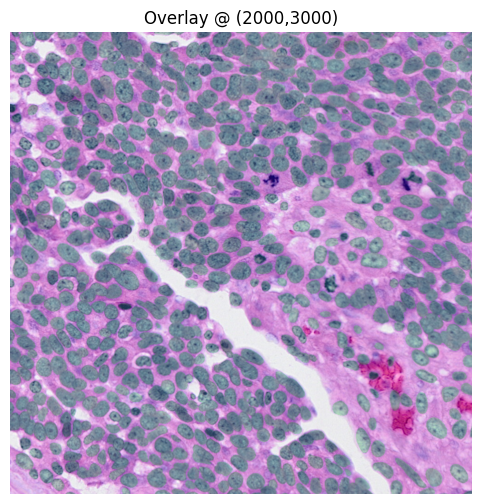

In [10]:
# --- Define crop location ---
x, y = 2000, 3000   # top-left corner
h, w = 1000, 1000

orig_crop = image[y:y+h, x:x+w]
labels_crop = nuclei_labels[y:y+h, x:x+w]

# --- Overlay ---
mask = labels_crop > 0

overlay = orig_crop.copy()
overlay[mask] = [0, 255, 0]

alpha = 0.2
blended = cv2.addWeighted(overlay, alpha, orig_crop, 1 - alpha, 0)

# --- Plot ---
plt.figure(figsize=(6, 6))
plt.imshow(blended)
plt.title(f"Overlay @ ({x},{y})")
plt.axis("off")
plt.show()

# Step 1: Run UNI on the cell patches

### Extract cell centroids from the segmentation mask

In [11]:
from skimage.measure import regionprops

# Compute region properties
regions = regionprops(nuclei_labels)

# Extract centroids
data = []
for r in regions:
    y, x = r.centroid   # NOTE: (row, col) = (y, x)
    data.append({
        "cell_id": r.label,
        "x": x,
        "y": y
    })

segm_coords = pd.DataFrame(data)

print(segm_coords.head())

   cell_id           x          y
0        1   32.710288  16.958848
1        2  285.796687   8.944277
2        3  337.133238   9.134670
3        4  547.253927   7.931937
4        5  645.047767  12.844237


### Configure UNI weights

In [ ]:
# Update this path to point to your local UNI checkpoint
PATH_UNI_WEIGHTS = pl.Path('/path/to/uni/pytorch_model.bin')

In [13]:
def load_UNI_model(model_path: str, device: str = "cuda"):
    timm_kwargs = {
        'model_name': 'vit_giant_patch14_224',
        'img_size': 224,
        'patch_size': 14,
        'depth': 24,
        'num_heads': 24,
        'init_values': 1e-5,
        'embed_dim': 1536,
        'mlp_ratio': 2.66667 * 2,
        'num_classes': 0,
        'no_embed_class': True,
        'mlp_layer': timm.layers.SwiGLUPacked,
        'act_layer': torch.nn.SiLU,
        'reg_tokens': 8,
        'dynamic_img_size': True
    }

    model = timm.create_model(pretrained=False, **timm_kwargs)
    model.load_state_dict(torch.load(model_path, map_location="cpu"), strict=True)
    model.eval().to(device)

    transform = transforms.Compose([
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.485, 0.456, 0.406),
                             std=(0.229, 0.224, 0.225)),
    ])
    return model, transform


def embed_UNI(wsi, cell_names, he_coords, output_dir, model_path, batch_size = 128, device = "cuda"):

    print('Load UNI model')
    model, transform = load_UNI_model(model_path, device)

    os.makedirs(output_dir, exist_ok=True)

    embeddings = []
    cell_ids = []
    
    batch_imgs = []
    batch_ids = []
    
    print(f"Embedding {len(he_coords)} image patches in batches of {batch_size}...")
    for cid, (x, y) in tqdm(zip(cell_names, he_coords), total=len(cell_names)):
        x, y = int(x), int(y)
        x0, x1 = x - 128, x + 128
        y0, y1 = y - 128, y + 128
    
        pad_x0 = max(0, -x0)
        pad_x1 = max(0, x1 - wsi.shape[1])
        pad_y0 = max(0, -y0)
        pad_y1 = max(0, y1 - wsi.shape[0])
    
        patch = np.pad(
            wsi[max(0, y0):min(wsi.shape[0], y1), max(0, x0):min(wsi.shape[1], x1)],
            ((pad_y0, pad_y1), (pad_x0, pad_x1), (0, 0)),
            mode="constant"
        )
    
        if patch.shape[:2] != (256, 256):
            continue
    
        tensor_img = transform(Image.fromarray(patch))
        batch_imgs.append(tensor_img)
        batch_ids.append(cid)
    
        if len(batch_imgs) == batch_size:
            img_tensor = torch.stack(batch_imgs).to(device)
    
            with torch.inference_mode(), torch.autocast(device_type=device, dtype=torch.float16):
                batch_embs = model(img_tensor).to(torch.float16).cpu().numpy()
    
            embeddings.extend(batch_embs)
            cell_ids.extend(batch_ids)
            batch_imgs.clear()
            batch_ids.clear()
    
    # Final batch (if any)
    if batch_imgs:
        img_tensor = torch.stack(batch_imgs).to(device)
        with torch.inference_mode(), torch.autocast(device_type=device, dtype=torch.float16):
            batch_embs = model(img_tensor).to(torch.float16).cpu().numpy()
        embeddings.extend(batch_embs)
        cell_ids.extend(batch_ids)

    # Save embedding matrix
    df = pd.DataFrame(embeddings, index=cell_ids)
    df.to_parquet(f"{output_dir}/UNI_crop.parquet")
    print(f"Saved {len(df)} embeddings to {output_dir}/UNI_crop.parquet")    

### Run UNI embedding

In [14]:
output_dir = 'data/'
device = "cuda" if torch.cuda.is_available() else "cpu"

# `cell_names` and `he_coords` define the order that will be used downstream
model_path = PATH_UNI_WEIGHTS

cell_names = segm_coords.cell_id.values.astype(str)
he_coords = segm_coords[['x','y']].values

In [15]:
embed_UNI(
    image,
    cell_names,
    he_coords,
    output_dir,
    model_path,
    batch_size = 512,
    device = device
)

Load UNI model
Embedding 41327 image patches in batches of 512...


  0%|          | 0/41327 [00:00<?, ?it/s]

Saved 41327 embeddings to data//UNI_crop.parquet


# Step 2: Embed using SpatialFusion (H&E)

### Load the saved UNI embeddings

In [ ]:
from spatialfusion.embed.embed import AEInputs, run_full_embedding

In [ ]:
output_dir = 'data/'

In [18]:
uni_df = pd.read_parquet(pl.Path(output_dir) / 'UNI_crop.parquet')

### Configure SpatialFusion checkpoints

In [20]:
# The AE checkpoint stays the multimodal pretrained model
ae_model_path = pl.Path('../src/spatialfusion/data/checkpoint_dir_ae/spatialfusion-multimodal-ae.pt')
# Important: point the GCN checkpoint to the H&E-only SpatialFusion variant
gcn_model_path = pl.Path('../src/spatialfusion/data/checkpoint_dir_gcn/spatialfusion-he-gcn.pt')

Now we build a fake adata just to keep the format consistent with the multimodal version. It needs to have the coordinates of the cells in `adata.obsm['spatial']` and consistent indexing. 

### Build the AnnData container used by the embedding code

In [21]:
adata = sc.AnnData(uni_df)
# Use the segmentation-derived centroids in the same row order as the UNI parquet
adata.obsm['spatial'] = segm_coords[['x','y']].values

/home/sabrina/miniforge3/envs/spatialfusion/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [22]:
# can run this for several samples at a time
# the second input is None here in H&E only
ae_inputs_by_sample = {
    'crop': AEInputs(adata=adata, z_uni=uni_df, z_scgpt=None),
}

# `combine_mode="z1"` is the H&E-only path through the model
emb_df = run_full_embedding(
    ae_inputs_by_sample=ae_inputs_by_sample,
    device=device,
    combine_mode="z1", # IMPORTANT! z1= H&E only mode
    spatial_key='spatial',
    celltype_key='major_celltype',
    ae_model_path=ae_model_path,
    gcn_model_path=gcn_model_path,
    save_ae_dir=None,  # optional
)

Running GCN inference: 100%|██████████| 1/1 [00:00<00:00,  1.81it/s]


In [23]:
emb_df.columns = emb_df.columns.astype(str)

# Align the embedding rows back to the AnnData cell order before clustering
adata.obsm['SpatialFusion'] = emb_df.set_index('cell_id').loc[adata.obs_names,['0','1','2','3','4','5','6','7','8','9']]

# Step 3: Cluster to obtain niches

In [29]:
sc.pp.neighbors(adata, use_rep='SpatialFusion')

In [30]:
sc.tl.leiden(adata, resolution=0.03, flavor="igraph", n_iterations=2)
# Display number of clusters
adata.obs.leiden.value_counts()

leiden
0    23435
2     6894
4     4254
5     3586
3     2824
1      334
Name: count, dtype: int64

In [31]:
adata.obs['X_coord'] = adata.obsm['spatial'][:,0]
adata.obs['Y_coord'] = adata.obsm['spatial'][:,1]

### Visualize niches in space

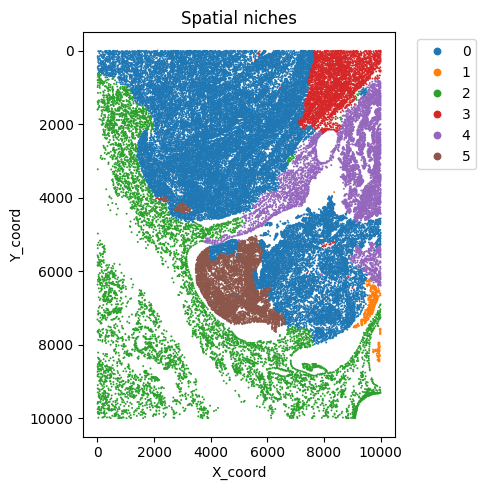

In [32]:
adata.obs['leiden'] = adata.obs['leiden'].astype(str).astype('category')
plt.style.use('default')

fig, ax = plt.subplots(1, 1, figsize=(5, 5))

# --- Plot 1: Spatial niches ---
sns.scatterplot(
    ax=ax,
    data=adata.obs,
    x='X_coord', y='Y_coord',
    hue='leiden',
    palette='tab10',
    s=2,
    linewidth=0
)
ax.invert_yaxis()
ax.set_title("Spatial niches")
ax.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    scatterpoints=1,
    markerscale=4
)

plt.tight_layout()

### Overlay niches on the H&E

This last plot uses a manually chosen region of interest in whole-slide image coordinates, so it is easy to change `xlim` and `ylim` to inspect a different area.

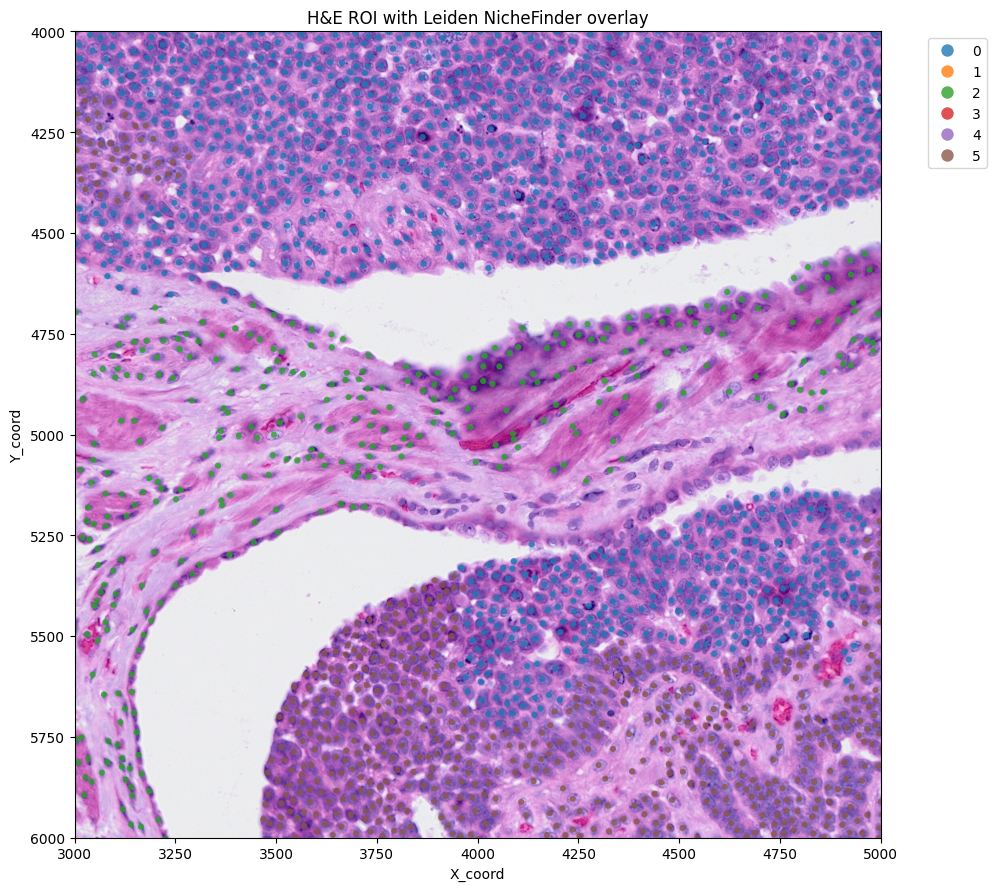

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Region of interest in H&E pixel space
xlim = (3000, 5000)
ylim = (4000, 6000)

x0, x1 = xlim
y0, y1 = ylim

# --- Crop ROI from the WSI
roi = image[y0:y1, x0:x1, :]  # note: numpy indexing is [row=y, col=x]

fig, ax = plt.subplots(figsize=(10, 10))

# Show the H&E ROI
ax.imshow(roi, origin="upper", extent=(x0, x1, y1, y0))  
# ^ extent maps the array coords into the same coordinate system as X_he, Y_he
#   origin="upper" keeps top-left = (0,0)

# Overlay scatter using aligned coords
sns.scatterplot(
    data=adata.obs,
    x="X_coord", y="Y_coord",
    hue="leiden",          # categorical cluster
    palette="tab10",
    s=20, alpha=0.8,
    ax=ax,
    linewidth=0
)

# Match the crop window
ax.set_xlim(x0, x1)
ax.set_ylim(y1, y0)  # because origin="upper" flips Y

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    scatterpoints=1,       # how many points to show per entry
    markerscale=2          # scale factor for the legend markers
)
ax.set_title("H&E ROI with Leiden NicheFinder overlay")

plt.tight_layout()
plt.show()
